# DS/AI: Data Science Group Assignment - Great Cormorant

**Group name:** minecraft

**Student names & numbers:**
* Gabriel Chitarliev - 98920
* Aleksandar Manev - 99052
* Alexander Atanasov - 101953
* Dimitar Yosifov - 00099118

---

## Setup

**Import libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import contextily as cx
import numpy as np

**Load dataset**

In [2]:
df_sightings = pd.read_csv('./Phalacrocorax carbo.csv',sep=',', low_memory=False)
df_habitats = pd.read_csv('./habitats_cbs_2022.csv', sep=',', low_memory=False)

knmi = pd.read_csv(
    "KNMI.txt",
    comment="#",
    names=["STN", "YYYYMMDD", "FG", "TG", "TN", "TX", "SQ", "Q", "RH", "UG"],
    skipinitialspace=True,
)

df = pd.read_csv(
    "bird_and_habitats.csv",
    parse_dates=["eventDate"],
    low_memory=False,
)


In [3]:
df["month"] = df["eventDate"].dt.month
df["day_of_year"] = df["eventDate"].dt.dayofyear

In [4]:
knmi["date"] = pd.to_datetime(knmi["YYYYMMDD"], format="%Y%m%d")

knmi["RH"] = knmi["RH"].replace(-1, 0)
knmi["SQ"] = knmi["SQ"].replace(-1, 0)

for col in ["TG", "TN", "TX", "FG", "RH", "SQ"]:
    knmi[col] = knmi[col] / 10

knmi.head(5)

,STN,YYYYMMDD,FG,TG,TN,TX,SQ,Q,RH,UG,date
0,240,20100101,4.6,-1.6,-6.3,0.8,5.0,343.0,0.0,82.0,2010-01-01
1,240,20100102,4.3,-0.6,-5.5,1.6,0.3,146.0,0.7,95.0,2010-01-02
2,240,20100103,2.8,-3.4,-7.5,-0.5,5.2,360.0,0.0,91.0,2010-01-03
3,240,20100104,4.1,-1.5,-5.1,1.2,1.4,201.0,0.3,97.0,2010-01-04
4,240,20100105,3.9,-0.2,-2.2,2.0,0.8,195.0,0.4,95.0,2010-01-05


In [5]:
# df = df_sightings.merge(
#     df_habitats,
#     on=["decimalLatitude", "decimalLongitude"],
#     how="inner",
# )

STATIONS = {
    240: (52.318, 4.790),   # Schiphol
    260: (52.100, 5.180),   # De Bilt
    270: (53.224, 5.752),   # Leeuwarden
    280: (53.125, 6.585),   # Eelde
    290: (52.274, 6.891),   # Twenthe
    310: (51.442, 3.596),   # Vlissingen
    330: (51.992, 4.122),   # Hoek van Holland
    344: (51.962, 4.447),   # Rotterdam
    380: (50.906, 5.762),   # Maastricht
    391: (51.498, 6.197),   # Arcen
}

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

cells = df[["decimalLatitude", "decimalLongitude"]].drop_duplicates().reset_index(drop=True)

stn_ids  = np.array(list(STATIONS.keys()))
stn_lats = np.array([s[0] for s in STATIONS.values()])
stn_lons = np.array([s[1] for s in STATIONS.values()])

dist = haversine_km(
    cells["decimalLatitude"].values[:, None],
    cells["decimalLongitude"].values[:, None],
    stn_lats[None, :],
    stn_lons[None, :],
)
cells["STN"] = stn_ids[dist.argmin(axis=1)]

print("Grid cells per station:")
print(cells["STN"].value_counts().sort_index())
cells.head()
leftover = ["STN", "STN_x", "STN_y", "TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q", "date"]

df = df.drop(columns=[c for c in leftover if c in df.columns])

df = df.merge(cells, on=["decimalLatitude", "decimalLongitude"], how="left")

df = df.merge(
    knmi[["STN", "date", "TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q"]],
    left_on=["STN", "eventDate"],
    right_on=["STN", "date"],
    how="left",
).drop(columns=["date"])

Grid cells per station:
STN
240    198
260    345
270    286
280    306
290    266
310    160
330     59
344    202
380    120
391    207
Name: count, dtype: int64


In [6]:
print("Shape:", knmi.shape)
knmi.head(11)

Shape: (59589, 11)


,STN,YYYYMMDD,FG,TG,TN,TX,SQ,Q,RH,UG,date
0,240,20100101,4.6,-1.6,-6.3,0.8,5.0,343.0,0.0,82.0,2010-01-01
1,240,20100102,4.3,-0.6,-5.5,1.6,0.3,146.0,0.7,95.0,2010-01-02
2,240,20100103,2.8,-3.4,-7.5,-0.5,5.2,360.0,0.0,91.0,2010-01-03
3,240,20100104,4.1,-1.5,-5.1,1.2,1.4,201.0,0.3,97.0,2010-01-04
4,240,20100105,3.9,-0.2,-2.2,2.0,0.8,195.0,0.4,95.0,2010-01-05
5,240,20100106,3.4,-2.8,-6.6,0.3,5.5,449.0,2.8,95.0,2010-01-06
6,240,20100107,2.7,-4.8,-11.5,-2.4,4.7,376.0,0.0,94.0,2010-01-07
7,240,20100108,4.0,-5.7,-13.8,-2.2,2.1,246.0,0.0,95.0,2010-01-08
8,240,20100109,10.0,-1.8,-4.5,-0.4,0.0,198.0,0.6,88.0,2010-01-09
9,240,20100110,7.0,-0.1,-0.6,0.4,0.0,80.0,1.7,95.0,2010-01-10


In [7]:
df.head(3)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,1,380,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,2,380,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,3,380,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0


In [8]:
print("Shape:", df.shape)
df.head(3)

Shape: (12558756, 26)


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,1,380,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,2,380,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,3,380,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0


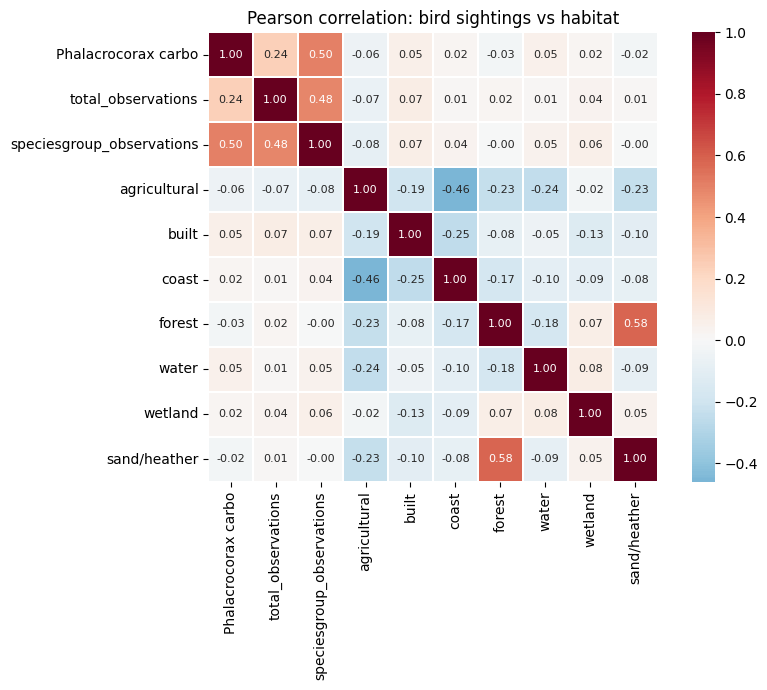

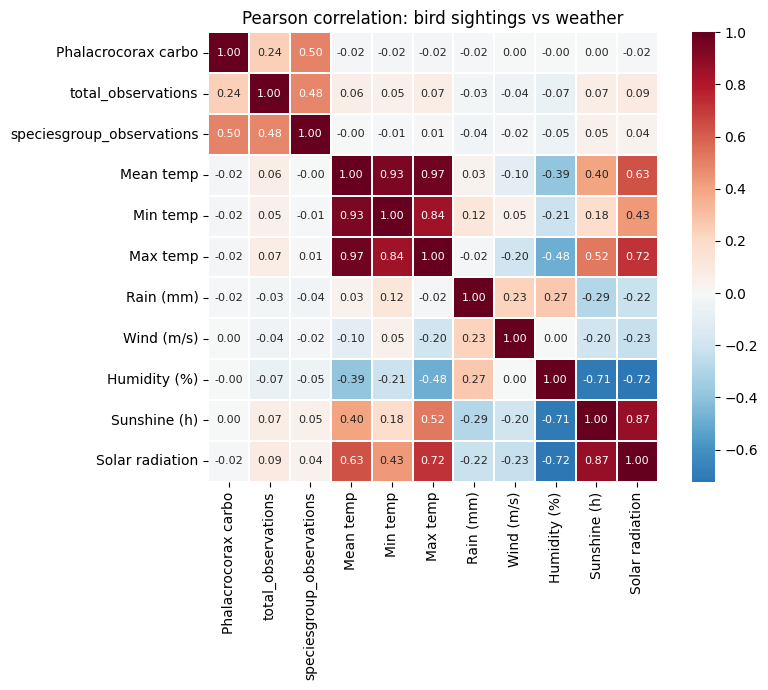

In [9]:
# Split the variables into groups so we get smaller, easier-to-read matrixes
bird_cols    = ["Phalacrocorax carbo", "total_observations", "speciesgroup_observations"]
habitat_cols = ["agricultural", "built", "coast", "forest", "water", "wetland", "sand/heather"]
weather_cols = ["TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q"]

pretty = {
    "TG": "Mean temp",
    "TN": "Min temp",
    "TX": "Max temp",
    "RH": "Rain (mm)",
    "FG": "Wind (m/s)",
    "UG": "Humidity (%)",
    "SQ": "Sunshine (h)",
    "Q":  "Solar radiation",
}

def plot_corr(cols, title, method="pearson"):
    corr = df[cols].corr(method=method).rename(index=pretty, columns=pretty)
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                square=True, linewidths=0.3, annot_kws={"size": 8})
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Matrix 1 - bird sightings vs habitat
plot_corr(bird_cols + habitat_cols, "Pearson correlation: bird sightings vs habitat")

# Matrix 2 - bird sightings vs weather
plot_corr(bird_cols + weather_cols, "Pearson correlation: bird sightings vs weather")

---

## 1. Business Understanding

**Business objective(s)**

- Balancing the conservation of the Great Cormorant with the economic viability of the Dutch inland fisheries and aquaculture sectors. The primary goal is to provide a data-driven framework that minimizes 'serious damage' to fish stocks and commercial yields through targeted management strategies and predictive impact modeling.


**Business success criteria**



**Data mining goal(s)**

- Use Latitude/Longitude data to identify "hotspots" where high cormorant density overlaps with high-value fishing/aquaculture zones

- Build a model to correlate cormorant sightings with actual fish stock depletion or wounding rates.

**Data mining success criteria**

- The model identifies high-impact zones with a Precision of >80%, ensuring that management resources are not wasted on low-impact areas.

# 2. Data Understanding


In [10]:
# df_sightings = pd.read_csv('./Phalacrocorax carbo.csv',sep=',', low_memory=False)
# df_habitats = pd.read_csv('./habitats_cbs_2022.csv', sep=',', low_memory=False)

# df = df_sightings.merge(
#     df_habitats,
#     on=["decimalLatitude", "decimalLongitude"],
#     how="inner",
# )

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 26 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[ns]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Phalacrocorax carbo        int64         
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               object        
 15  month                      int32         
 16  day_of_year                int32  

In [12]:
print(df_sightings["Phalacrocorax carbo"].unique())

['0' '1' '2' '4' '3' '5' '6' '7' '10' '11' '20' '9' '8' '15' '17' '16'
 '12' '14' '24' '22' '25' '21' '27' '18' '50' '13' '28' '26' '35' '23'
 '19' '43' '56' '36' '30' '41' '62' '32' '37' '34' '31' '51' '67' '29'
 '42' '55' '109' '45' '57' '58' '38' '33' '63' '-1' 'unknown']


In [13]:
# df.to_csv('bird_and_habitats.csv', index=False)

In [14]:
df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
cols = [
    "total_observations",
    "speciesgroup_observations",
    "Phalacrocorax carbo"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 26 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[ns]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Phalacrocorax carbo        int64         
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               object        
 15  month                      int32         
 16  day_of_year                int32  

In [16]:
df['year'] = df['eventDate'].dt.year
df['month'] = df['eventDate'].dt.month
df['week'] = df['eventDate'].dt.isocalendar().week

In [17]:
df.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0,2010,53
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0,2010,53
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0,2010,53
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-5.4,-10.5,-3.0,0.4,3.3,89.0,0.4,218.0,2010,1
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-2.3,-4.6,-1.0,0.4,3.5,92.0,0.0,177.0,2010,1


In [18]:
df.tail(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
12558751,53.5,6.55,2025-12-27,0.0,0,0,0.0353,0.0,18.4195,0.0,...,3.4,-2.4,7.2,0.0,2.2,90.0,0.5,126.0,2025,52
12558752,53.5,6.55,2025-12-28,0.0,0,0,0.0353,0.0,18.4195,0.0,...,0.3,-3.2,4.4,0.0,1.4,97.0,1.7,198.0,2025,52
12558753,53.5,6.55,2025-12-29,0.0,0,0,0.0353,0.0,18.4195,0.0,...,5.2,1.1,7.4,0.2,3.3,83.0,0.5,141.0,2025,1
12558754,53.5,6.55,2025-12-30,0.0,0,0,0.0353,0.0,18.4195,0.0,...,3.2,-2.1,6.4,0.1,3.0,70.0,5.1,295.0,2025,1
12558755,53.5,6.55,2025-12-31,0.0,0,0,0.0353,0.0,18.4195,0.0,...,4.0,-1.1,7.4,0.1,5.2,89.0,1.7,195.0,2025,1


In [19]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
decimalLatitude,12558756.0,52.23006,50.75,51.7,52.2,52.8,53.5,0.660521
decimalLongitude,12558756.0,5.532783,3.35,4.9,5.65,6.2,7.2,0.874886
eventDate,12558756,2017-12-31 11:59:59.999999744,2010-01-01 00:00:00,2013-12-31 18:00:00,2017-12-31 12:00:00,2021-12-31 06:00:00,2025-12-31 00:00:00,NaN
total_observations,12558756.0,8.067763,0.0,0.0,1.0,6.0,100040.0,39.125017
speciesgroup_observations,12558756.0,4.330658,0.0,0.0,0.0,2.0,2779.0,16.067937
Phalacrocorax carbo,12558756.0,0.051434,0.0,0.0,0.0,0.0,109.0,0.336498
agricultural,12558756.0,9.452277,0.0,5.3484,10.5682,13.8008,18.1046,5.147907
built,12558756.0,2.404833,0.0,0.7667,1.5599,3.2916,14.3538,2.419758
coast,12558756.0,1.302932,0.0,0.0,0.0,0.0,19.3487,3.970215
forest,12558756.0,1.621184,0.0,0.1494,0.7092,2.0364,16.9985,2.385737


In [20]:
print(df[(df['Phalacrocorax carbo'] > 5) & (df['wetland'] == 0)]['main_habitat'].value_counts())

main_habitat
coast           655
built           154
agricultural    138
water            70
other            11
forest            2
Name: count, dtype: int64


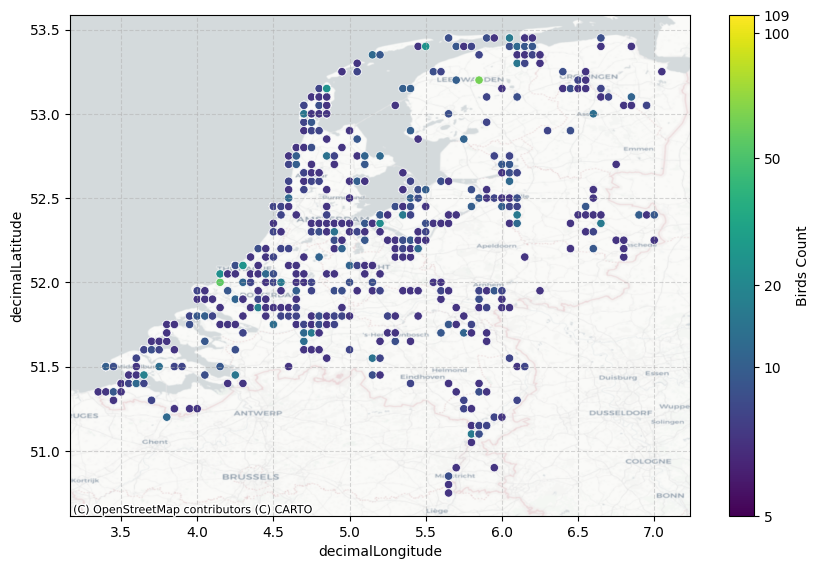

In [21]:
dfX = df[(df['Phalacrocorax carbo'] > 5) & (df['year'] >= 2020) & (df['year'] <= 2025) ]
my_norm = colors.PowerNorm(gamma=0.4, vmin=5, vmax=109)

plt.figure(figsize=(10, 6.5))
# 1. Plot (notice legend=False)
ax = sns.scatterplot(
    data=dfX, x='decimalLongitude', y='decimalLatitude', 
    hue='Phalacrocorax carbo', hue_norm=my_norm, palette='viridis', legend=False
)

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
# 2. Add a colorbar and force your exact numbers onto it
sm = plt.cm.ScalarMappable(cmap='viridis', norm=my_norm)
cbar = plt.colorbar(sm, ax=ax, label='Birds Count')
cbar.set_ticks([5, 10, 20, 50, 100, 109])

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

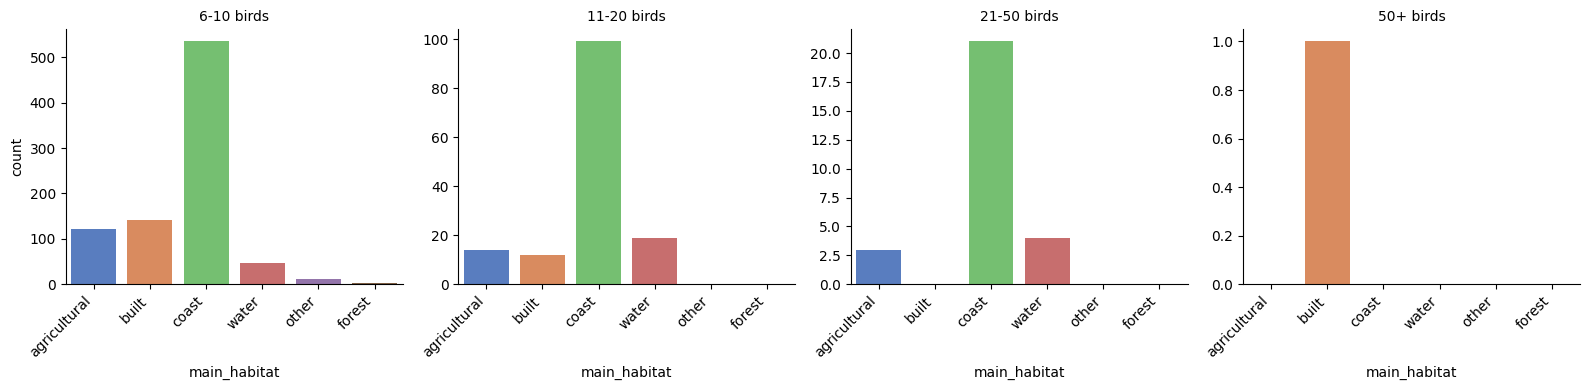

In [22]:
# 1. Filter out wetlands and bucket the counts
df_non_wetland = df[df['wetland'] == 0].copy()
df_non_wetland['bird_brackets'] = pd.cut(
    df_non_wetland['Phalacrocorax carbo'], 
    bins=[5, 10, 20, 50, float('inf')], 
    labels=['6-10 birds', '11-20 birds', '21-50 birds', '50+ birds']
)
df_filtered = df_non_wetland.dropna(subset=['bird_brackets'])

# 2. Use catplot to split into separate subplots side-by-side
g = sns.catplot(
    data=df_filtered,
    x='main_habitat',
    hue='main_habitat',
    col='bird_brackets',    # Creates a separate plot for each bracket
    kind='count',
    sharey=False,           # CRITICAL: Gives each plot its own Y-axis scale!
    palette='muted',
    height=4,
    aspect=1.0
)

# Rotate habitat labels so they don't overlap
g.set_xticklabels(rotation=45, ha='right')
g.set_titles("{col_name}") # Cleans up the subplot titles

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_13164\3962132312.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


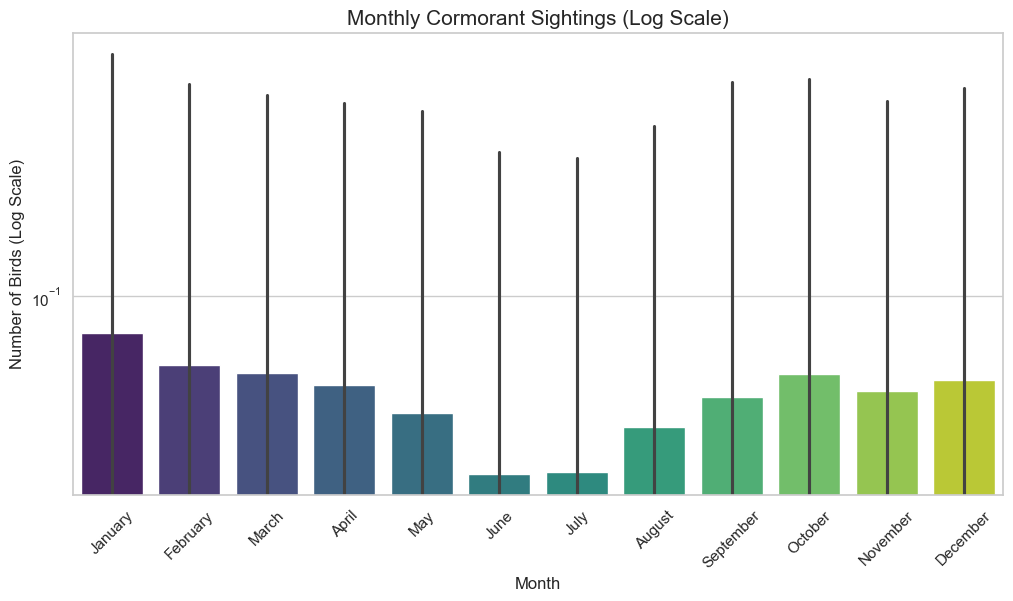

In [23]:
# 1. Ensure numeric and handle zeros
# We add a tiny amount (1) to the count if we want to include zero-sighting records 
# in a log plot, otherwise log(0) causes errors.
# 1. Re-create the time features from the eventDate string
df['eventDate'] = pd.to_datetime(df['eventDate'])
df['month_num'] = df['eventDate'].dt.month
df['month_name'] = df['eventDate'].dt.month_name()

# 2. Setup the plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Sort by month_num so it goes Jan -> Dec, not alphabetical
df_sorted = df.sort_values('month_num')

# 4. The Bar Chart
ax = sns.barplot(
    data=df_sorted, 
    x='month_name', 
    y='Phalacrocorax carbo',
    palette='viridis',
    errorbar='sd' # Standard deviation is better for this noisy data
)

# 5. Apply the Log Scale (essential for bird counts)
# We use a small offset (e.g., 0.1) if there are zeros to avoid math errors
ax.set_yscale("log")

# 6. Labels and Formatting
plt.title('Monthly Cormorant Sightings (Log Scale)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Birds (Log Scale)', fontsize=12)
plt.xticks(rotation=45)

plt.show()

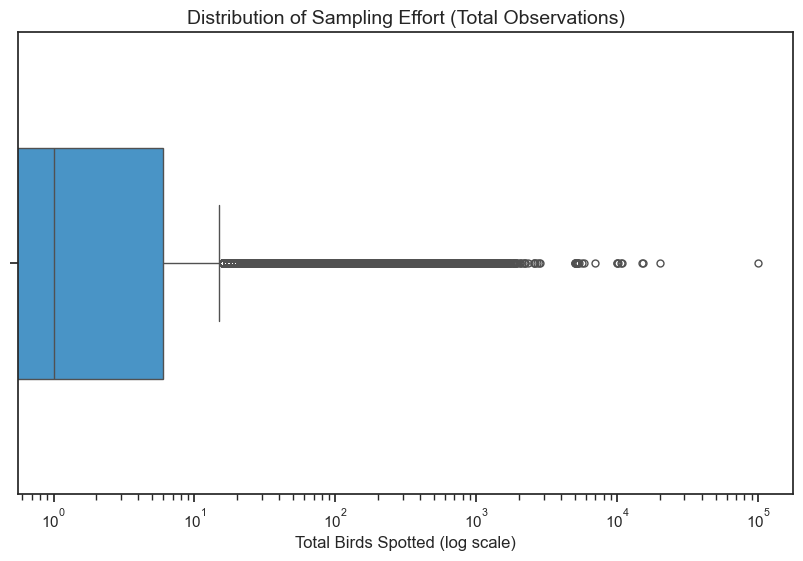

In [24]:
# 1. Setup the figure
plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")

# 2. Create the Boxplot
# We'll plot it vertically to see the distribution of effort
ax = sns.boxplot(
    x=df['total_observations'], 
    color='#3498db',
    width=0.5,
    fliersize=5  # Size of the outlier dots
)

# 3. Add a log scale (Highly recommended for 'total_observations')
# Sampling effort usually ranges from 1 to 10,000; without log, 
# the 'box' will look like a flat line at the bottom.
ax.set_xscale("log")

# 4. Labels
plt.title('Distribution of Sampling Effort (Total Observations)', fontsize=14)
plt.xlabel('Total Birds Spotted (log scale)', fontsize=12)

plt.show()

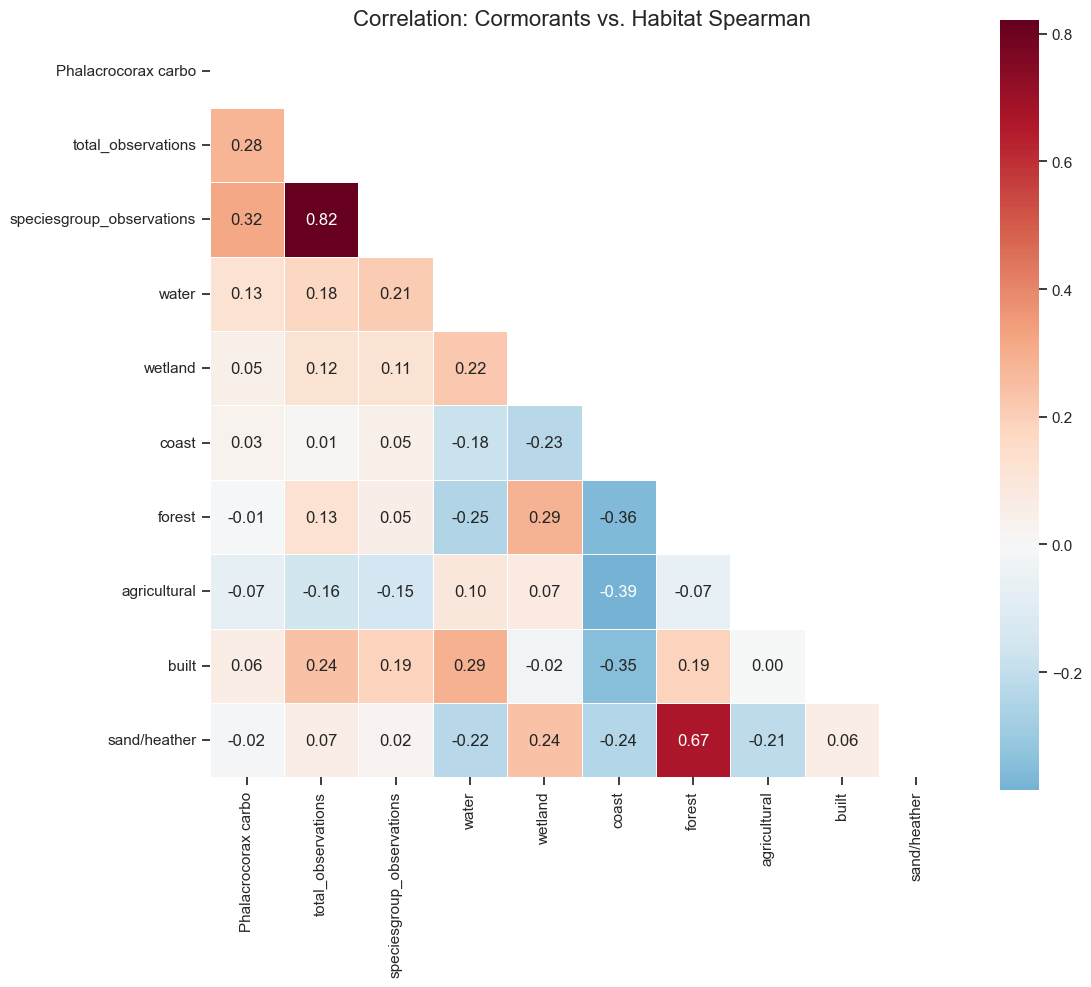

In [25]:
# 1. Select the target and the new habitat features
habitat_cols = [
    'Phalacrocorax carbo', 'total_observations', 'speciesgroup_observations', 'water', 'wetland', 
    'coast', 'forest', 'agricultural', 'built', 'sand/heather'
]

# Calculate correlation
corr_matrix = df[habitat_cols].corr(method="spearman")

# 2. Plotting
plt.figure(figsize=(12, 10))

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', # Red for positive, Blue for negative
    center=0,
    square=True,
    linewidths=.5
)

plt.title('Correlation: Cormorants vs. Habitat Spearman', fontsize=16)
plt.show()

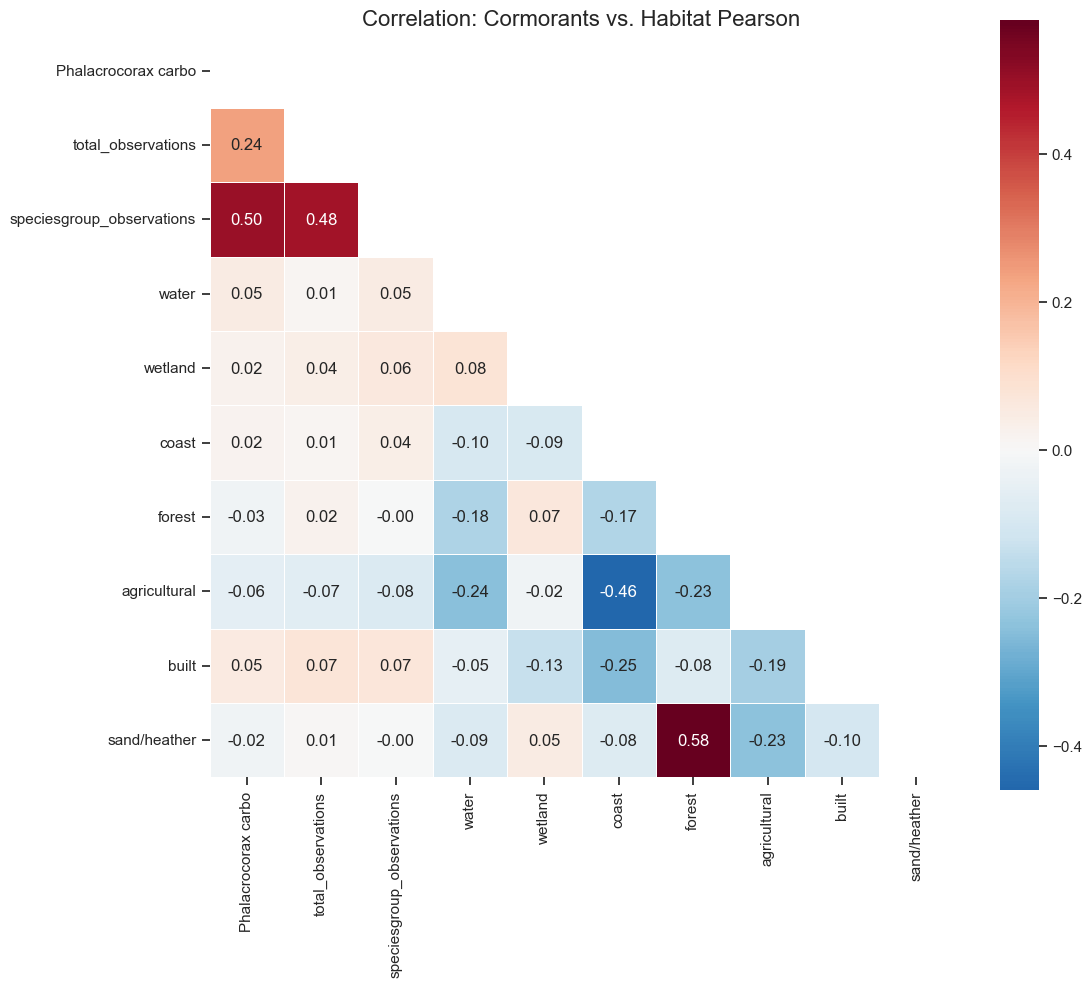

In [26]:
corr_matrix = df[habitat_cols].corr()

# 2. Plotting
plt.figure(figsize=(12, 10))

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', # Red for positive, Blue for negative
    center=0,
    square=True,
    linewidths=.5
)

plt.title('Correlation: Cormorants vs. Habitat Pearson', fontsize=16)
plt.show()

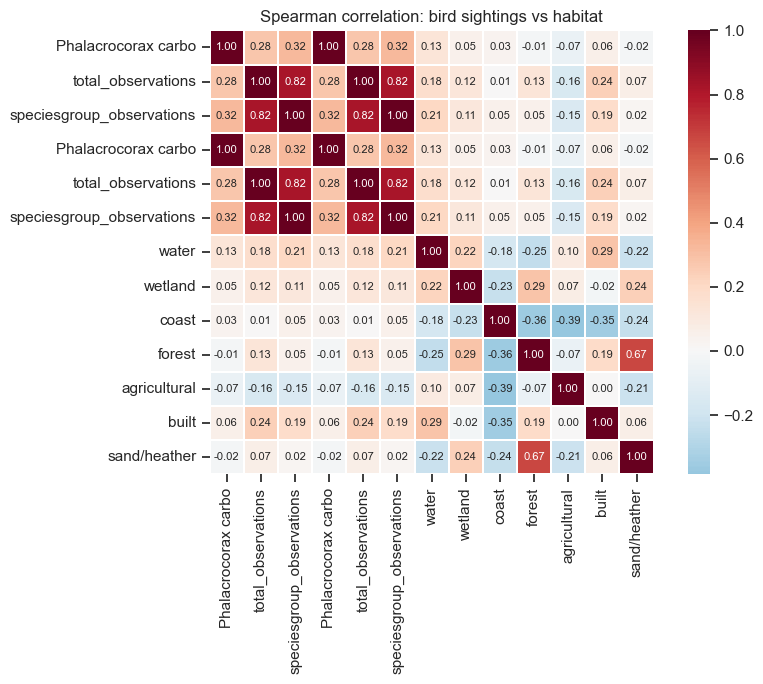

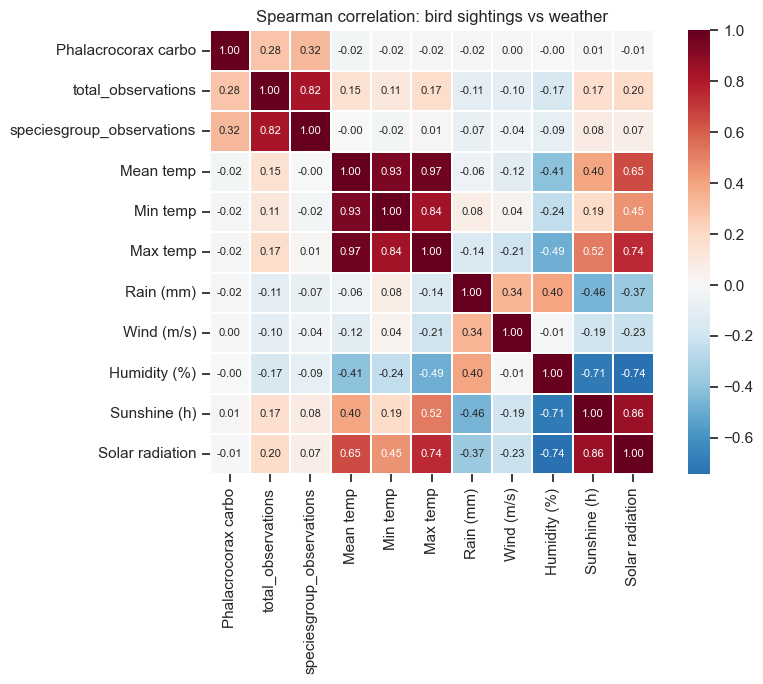

In [27]:
# Same split as above, but Spearman (rank-based, catches non-linear monotonic patterns)
plot_corr(bird_cols + habitat_cols, "Spearman correlation: bird sightings vs habitat", method="spearman")
plot_corr(bird_cols + weather_cols, "Spearman correlation: bird sightings vs weather", method="spearman")

## Cormorants seen vs temperature

We split the daily mean temperature (TG) into 2 °C ranges and plot the average number of cormorants seen per row in each range.

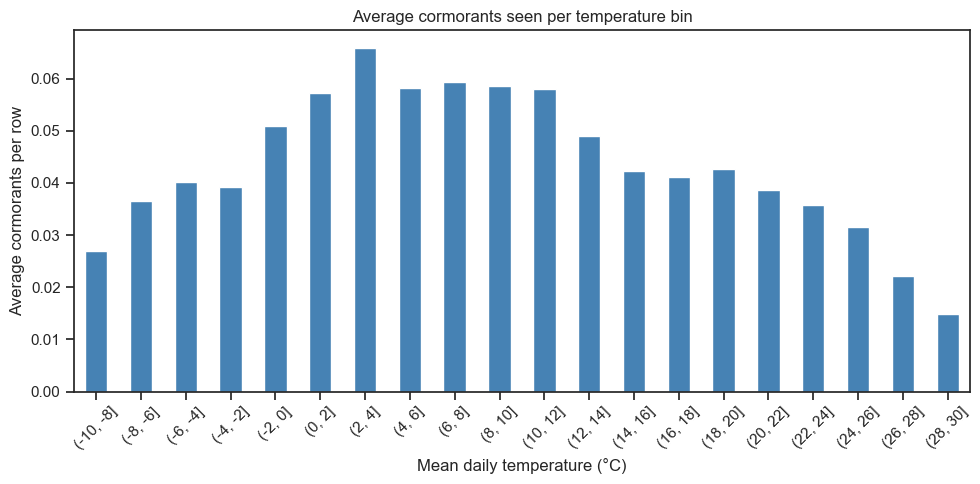

In [28]:
plot_df = df[["TG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["TG_bin"] = pd.cut(plot_df["TG"], bins=range(-10, 32, 2))
temp_means = plot_df.groupby("TG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
temp_means.plot(kind="bar", color="steelblue")
plt.title("Average cormorants seen per temperature bin")
plt.xlabel("Mean daily temperature (°C)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cormorants seen vs humidity

Same idea, but binned by daily mean humidity 

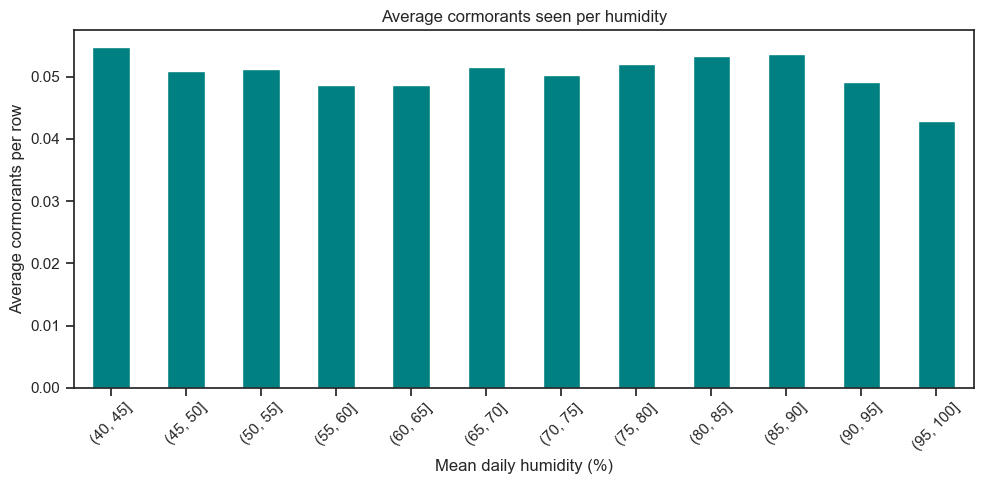

In [29]:
plot_df = df[["UG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["UG_bin"] = pd.cut(plot_df["UG"], bins=range(40, 101, 5))
hum_means = plot_df.groupby("UG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
hum_means.plot(kind="bar", color="teal")
plt.title("Average cormorants seen per humidity")
plt.xlabel("Mean daily humidity (%)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cormorants seen vs rain

Group days into 4 buckets - none / light / moderate / heavy - and check average sightings per bucket.

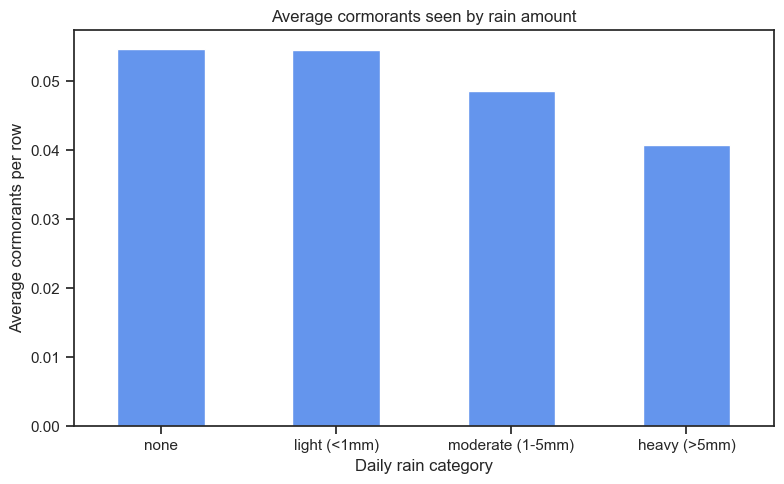

In [30]:
plot_df = df[["RH", "Phalacrocorax carbo"]].dropna().copy()
plot_df["rain_cat"] = pd.cut(
    plot_df["RH"],
    bins=[-0.1, 0, 1, 5, 1000],
    labels=["none", "light (<1mm)", "moderate (1-5mm)", "heavy (>5mm)"],
)
rain_means = plot_df.groupby("rain_cat", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(8, 5))
rain_means.plot(kind="bar", color="cornflowerblue")
plt.title("Average cormorants seen by rain amount")
plt.xlabel("Daily rain category")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Cormorants seen vs wind

Binned by daily mean wind speed (`FG`, in m/s).

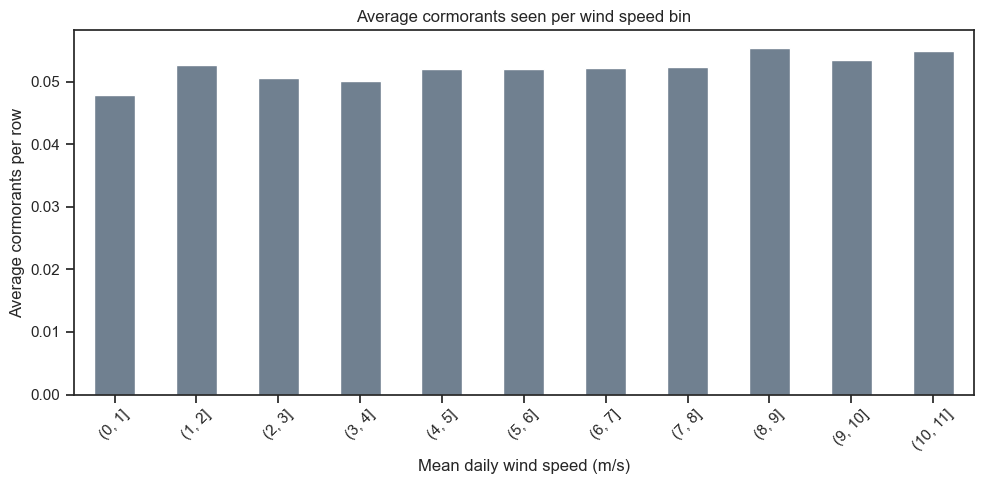

In [31]:
plot_df = df[["FG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["FG_bin"] = pd.cut(plot_df["FG"], bins=np.arange(0, 12, 1))
wind_means = plot_df.groupby("FG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
wind_means.plot(kind="bar", color="slategray")
plt.title("Average cormorants seen per wind speed bin")
plt.xlabel("Mean daily wind speed (m/s)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cormorants seen by month

Cormorants are migratory. We expect a clear seasonal pattern here - this is usually one of the strongest signals in any bird-sighting dataset.

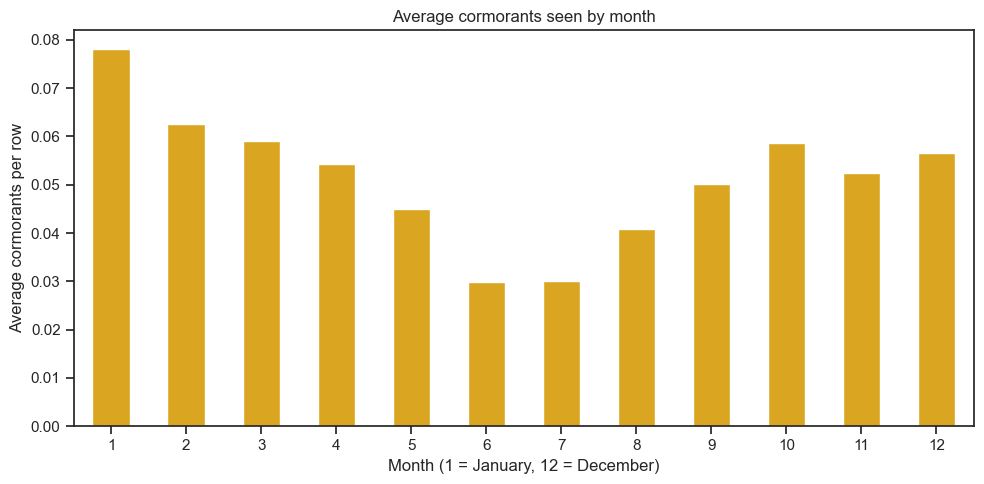

In [32]:
month_means = df.groupby("month")["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
month_means.plot(kind="bar", color="goldenrod")
plt.title("Average cormorants seen by month")
plt.xlabel("Month (1 = January, 12 = December)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Cormorants seen by day of year

Same idea, but at daily resolution. Catches finer migration patterns inside each month.

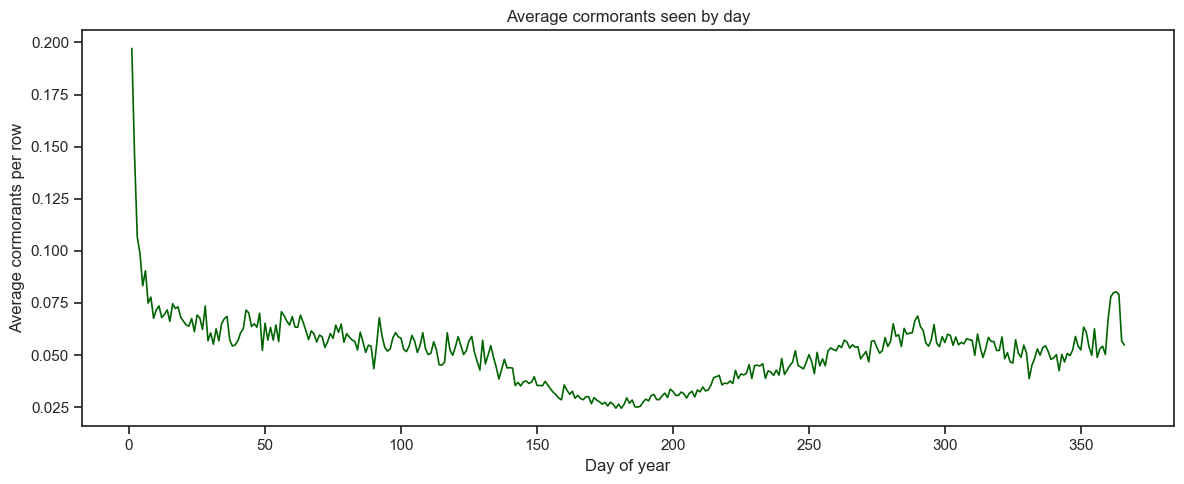

In [33]:
doy_means = df.groupby("day_of_year")["Phalacrocorax carbo"].mean()

plt.figure(figsize=(12, 5))
doy_means.plot(color="darkgreen", linewidth=1.2)
plt.title("Average cormorants seen by day")
plt.xlabel("Day of year")
plt.ylabel("Average cormorants per row")
plt.tight_layout()
plt.show()

## Cormorants seen by year


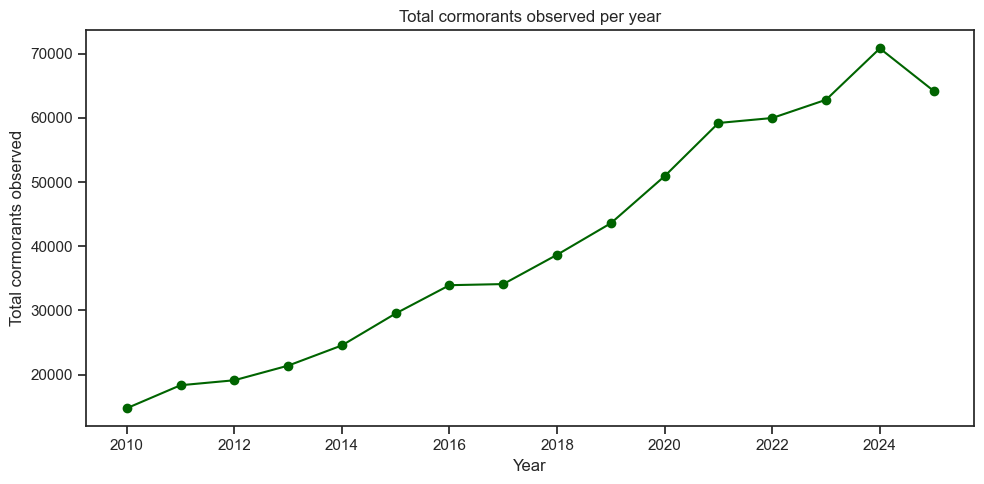

In [34]:
yearly = df.groupby(df["eventDate"].dt.year)["Phalacrocorax carbo"].sum()

plt.figure(figsize=(10, 5))
yearly.plot(kind="line", marker="o", color="darkgreen")
plt.title("Total cormorants observed per year")
plt.xlabel("Year")
plt.ylabel("Total cormorants observed")
plt.tight_layout()
plt.show()

## Cormorants per month over time


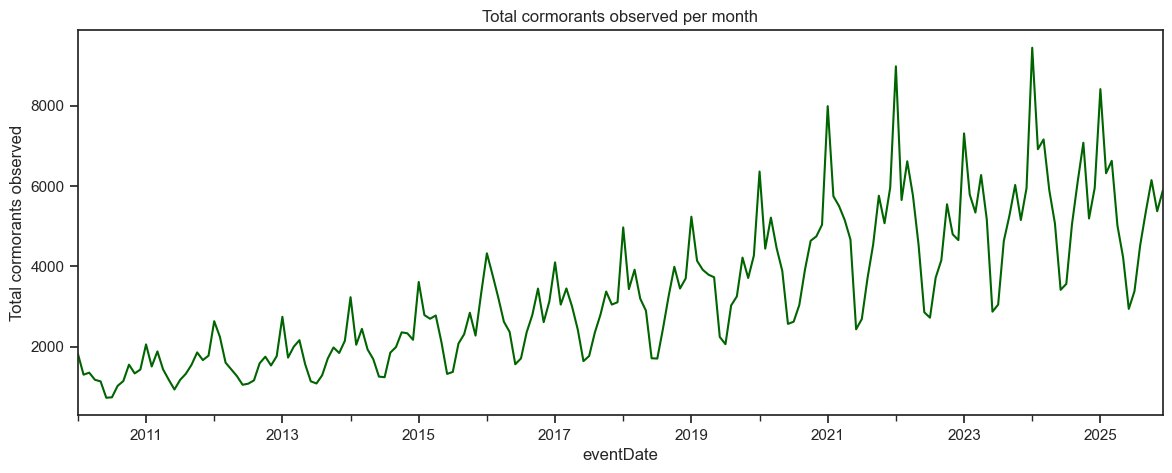

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df
# df_plot = pd.read_parquet("bird_habitats_weather.parquet")

monthly = df_plot.groupby(df_plot["eventDate"].dt.to_period("M"))["Phalacrocorax carbo"].sum()

monthly.plot(figsize=(14, 5), color="darkgreen")
plt.title("Total cormorants observed per month")
plt.ylabel("Total cormorants observed")
plt.show()

# 3. Modelling

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV

In [37]:
# df = pd.read_parquet('./bird_habitats_weather.parquet')

### Sampling

In [38]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TX,RH,FG,UG,SQ,Q,year,week,month_num,month_name
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-1.1,0.1,4.6,91.0,0.0,33.0,2010,53,1,January
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,0.2,0.2,4.9,90.0,2.7,260.0,2010,53,1,January
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,0.8,3.0,3.3,92.0,0.3,178.0,2010,53,1,January
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-3.0,0.4,3.3,89.0,0.4,218.0,2010,1,1,January
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-1.0,0.4,3.5,92.0,0.0,177.0,2010,1,1,January


In [39]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TN,TX,RH,FG,UG,SQ,Q,year,week,month_num
count,1.255876e+07,1.255876e+07,12558756,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,...,1.253764e+07,1.253764e+07,1.253764e+07,1.253608e+07,1.253764e+07,1.253630e+07,1.253630e+07,1.255876e+07,12558756.0,1.255876e+07
mean,5.223006e+01,5.532783e+00,2017-12-31 11:59:59.999999744,8.067763e+00,4.330658e+00,5.143431e-02,9.452277e+00,2.404833e+00,1.302932e+00,1.621184e+00,...,6.726166e+00,1.481465e+01,2.228206e+00,4.141858e+00,8.026855e+01,5.079891e+00,1.067049e+03,2.017500e+03,26.563997,6.522930e+00
min,5.075000e+01,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-1.950000e+01,-6.700000e+00,0.000000e+00,0.000000e+00,2.900000e+01,0.000000e+00,2.000000e+01,2.010000e+03,1.0,1.000000e+00
25%,5.170000e+01,4.900000e+00,2013-12-31 18:00:00,0.000000e+00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,...,2.600000e+00,9.300000e+00,0.000000e+00,2.600000e+00,7.400000e+01,1.200000e+00,3.340000e+02,2.013750e+03,14.0,4.000000e+00
50%,5.220000e+01,5.650000e+00,2017-12-31 12:00:00,1.000000e+00,0.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,...,6.900000e+00,1.470000e+01,1.000000e-01,3.700000e+00,8.200000e+01,4.400000e+00,9.030000e+02,2.017500e+03,27.0,7.000000e+00
75%,5.280000e+01,6.200000e+00,2021-12-31 06:00:00,6.000000e+00,2.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,...,1.120000e+01,2.030000e+01,2.400000e+00,5.200000e+00,8.800000e+01,8.200000e+00,1.674000e+03,2.021250e+03,40.0,1.000000e+01
max,5.350000e+01,7.200000e+00,2025-12-31 00:00:00,1.000400e+05,2.779000e+03,1.090000e+02,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,...,2.350000e+01,4.020000e+01,1.064000e+02,1.800000e+01,1.000000e+02,1.570000e+01,3.130000e+03,2.025000e+03,53.0,1.200000e+01
std,6.605211e-01,8.748856e-01,NaN,3.912502e+01,1.606794e+01,3.364980e-01,5.147907e+00,2.419758e+00,3.970215e+00,2.385737e+00,...,5.777645e+00,7.255706e+00,4.617264e+00,2.101596e+00,1.033570e+01,4.252923e+00,8.067607e+02,4.609698e+00,15.061596,3.448703e+00


### Filtering the data based on date

In [40]:
df_filtered = df[df['eventDate'].dt.year > 2019]

In [41]:
df_filtered.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TX,RH,FG,UG,SQ,Q,year,week,month_num,month_name
3652,50.75,5.65,2020-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,2.9,0.0,1.9,99.0,2.7,318.0,2020,1,1,January
3653,50.75,5.65,2020-01-02,2.0,2,0,1.7747,0.0568,0.0,0.0616,...,7.4,0.0,4.5,89.0,1.3,178.0,2020,1,1,January
3654,50.75,5.65,2020-01-03,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,9.4,4.9,5.8,92.0,0.0,71.0,2020,1,1,January
3655,50.75,5.65,2020-01-04,10.0,9,1,1.7747,0.0568,0.0,0.0616,...,6.9,0.1,3.6,90.0,1.9,237.0,2020,1,1,January
3656,50.75,5.65,2020-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,7.0,0.0,3.0,84.0,0.0,116.0,2020,1,1,January


In [42]:
df_filtered.dtypes

decimalLatitude                     float64
decimalLongitude                    float64
eventDate                    datetime64[ns]
total_observations                  float64
speciesgroup_observations             int64
Phalacrocorax carbo                   int64
agricultural                        float64
built                               float64
coast                               float64
forest                              float64
other                               float64
sand/heather                        float64
water                               float64
wetland                             float64
main_habitat                         object
month                                 int32
day_of_year                           int32
STN                                   int64
TG                                  float64
TN                                  float64
TX                                  float64
RH                                  float64
FG                              

In [43]:
df_filtered.tail(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TX,RH,FG,UG,SQ,Q,year,week,month_num,month_name
12558751,53.5,6.55,2025-12-27,0.0,0,0,0.0353,0.0,18.4195,0.0,...,7.2,0.0,2.2,90.0,0.5,126.0,2025,52,12,December
12558752,53.5,6.55,2025-12-28,0.0,0,0,0.0353,0.0,18.4195,0.0,...,4.4,0.0,1.4,97.0,1.7,198.0,2025,52,12,December
12558753,53.5,6.55,2025-12-29,0.0,0,0,0.0353,0.0,18.4195,0.0,...,7.4,0.2,3.3,83.0,0.5,141.0,2025,1,12,December
12558754,53.5,6.55,2025-12-30,0.0,0,0,0.0353,0.0,18.4195,0.0,...,6.4,0.1,3.0,70.0,5.1,295.0,2025,1,12,December
12558755,53.5,6.55,2025-12-31,0.0,0,0,0.0353,0.0,18.4195,0.0,...,7.4,0.1,5.2,89.0,1.7,195.0,2025,1,12,December


### Creating the seen column

In [44]:
# df_filtered['sasho'] = pd.to_numeric(pd.to_datetime(df_filtered['eventDate']))
# df_filtered['sasho1'] = pd.to_numeric(pd.to_datetime(df_filtered['date']))

In [45]:
df_filtered['seen'] = (df_filtered['Phalacrocorax carbo'] > 0).astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_13164\2711350578.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['seen'] = (df_filtered['Phalacrocorax carbo'] > 0).astype(int)


### Splitting the data

In [46]:
X = df_filtered.drop(columns=['Phalacrocorax carbo','seen'])
y = df_filtered['seen']

train_mask = df_filtered['eventDate'].dt.year <= 2023      # train 2020-2023
X_train, X_test = X[train_mask], X[~train_mask]            # test  2024-2025
y_train, y_test = y[train_mask], y[~train_mask]

In [47]:
X_train.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,...,TX,RH,FG,UG,SQ,Q,year,week,month_num,month_name
3652,50.75,5.65,2020-01-01,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,2.9,0.0,1.9,99.0,2.7,318.0,2020,1,1,January
3653,50.75,5.65,2020-01-02,2.0,2,1.7747,0.0568,0.0,0.0616,0.0582,...,7.4,0.0,4.5,89.0,1.3,178.0,2020,1,1,January
3654,50.75,5.65,2020-01-03,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,9.4,4.9,5.8,92.0,0.0,71.0,2020,1,1,January
3655,50.75,5.65,2020-01-04,10.0,9,1.7747,0.0568,0.0,0.0616,0.0582,...,6.9,0.1,3.6,90.0,1.9,237.0,2020,1,1,January
3656,50.75,5.65,2020-01-05,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,7.0,0.0,3.0,84.0,0.0,116.0,2020,1,1,January


In [48]:
X_train.dtypes

decimalLatitude                     float64
decimalLongitude                    float64
eventDate                    datetime64[ns]
total_observations                  float64
speciesgroup_observations             int64
agricultural                        float64
built                               float64
coast                               float64
forest                              float64
other                               float64
sand/heather                        float64
water                               float64
wetland                             float64
main_habitat                         object
month                                 int32
day_of_year                           int32
STN                                   int64
TG                                  float64
TN                                  float64
TX                                  float64
RH                                  float64
FG                                  float64
UG                              

In [49]:
y_train.head(5)

3652    0
3653    0
3654    0
3655    1
3656    0
Name: seen, dtype: int64

### Baseline model

In [50]:
from sklearn.ensemble import RandomForestClassifier

# Tuned hyperparameters settings

baseModel = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=2,
    min_samples_leaf=50,
    max_features="log2",
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Feature-leak fix: drop speciesgroup_observations
drop_cols = ['eventDate', 'main_habitat', 'month_name', 'speciesgroup_observations']
X_train_numeric = X_train.drop(columns=drop_cols, errors='ignore')
X_test_numeric = X_test.drop(columns=drop_cols, errors='ignore')

baseModel.fit(X_train_numeric, y_train)
print(baseModel.predict(X_test_numeric))

[0 1 0 ... 0 0 0]


In [51]:
import sklearn.metrics as skm
from sklearn.metrics import roc_curve, auc

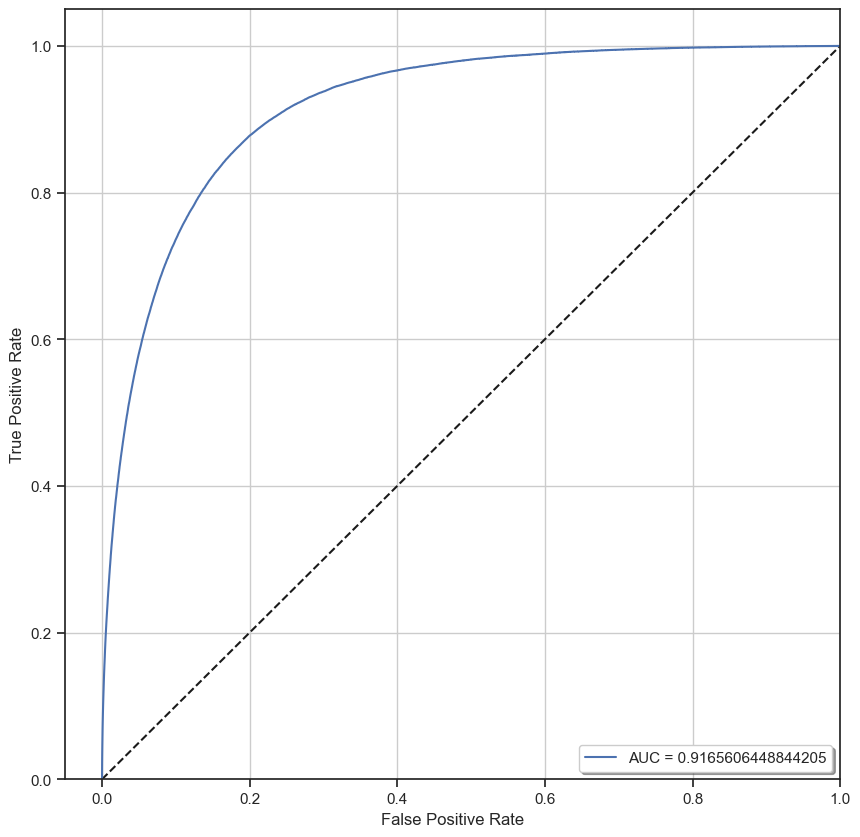

In [52]:
acc = baseModel.score(X_test_numeric,y_test)

Y_score = baseModel.predict_proba(X_test_numeric)[:,1]
fpr = dict()
tpr = dict()
fpr, tpr, sasho  = roc_curve(y_test, Y_score)

roc_auc = dict()
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,10))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.plot(fpr, tpr, label='AUC = {0}'.format(roc_auc))
plt.legend(loc="lower right", shadow=True, fancybox =True) 
plt.show()

In [53]:
print(acc)

0.8591455065474414


In [54]:
y_pred = baseModel.predict(X_test_numeric)

report = classification_report(y_test, y_pred)

In [55]:
print(report)

              precision    recall  f1-score   support

           0       0.99      0.86      0.92   1480603
           1       0.26      0.80      0.40     90316

    accuracy                           0.86   1570919
   macro avg       0.62      0.83      0.66   1570919
weighted avg       0.94      0.86      0.89   1570919



crazy burger model

In [56]:
def burger_model(row): 
    return 0

In [57]:
df_eval = df_filtered.copy()
df_eval['predicted_seen'] = df_eval.apply(lambda row: burger_model(row), axis=1)

y_true = df_filtered["seen"]
y_pred = df_eval["predicted_seen"]

In [58]:
report = classification_report(y_true, y_pred)

C:\Users\User\Desktop\the-greatest-cormorant\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\Desktop\the-greatest-cormorant\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\Desktop\the-greatest-cormorant\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [59]:
print(report)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97   4457739
           1       0.00      0.00      0.00    252869

    accuracy                           0.95   4710608
   macro avg       0.47      0.50      0.49   4710608
weighted avg       0.90      0.95      0.92   4710608

